Now that we have shown that the k-fold models generalize better to the test data than a random baseline, we will generate a new model with the best hyperparameters identified, but trained on the training + validation data. This is simply to have one coherent model for additional downstream assessments. It also should give the model better power.

In [1]:
import os

import pandas as pd
import scanpy as sc

import torch
import torch.nn as nn
import numpy as np
from geomloss import SamplesLoss

import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.insert(1, '../.')
from Kang_utils import get_best_hyperparams


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC


In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')

In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

# ensures correct order of test data
# note, this already saved in order, matching the mod.y_out columns
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [6]:
test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
train_cells = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]

In [30]:
res = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_k_fold_validation_results.csv'), index_col = 0)
best_emd_mean, best_hyperparams, best_emd = get_best_hyperparams(res)

trainers_best = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_trainers_k.pickle'))


Select a hyper-parameter tuning model that uses the most common KL regularization value:

In [31]:
kl_reg = best_emd.KL_regularization.value_counts().idxmax()

kl_og = np.nan
for k, trainer_k in trainers_best.items():
    if kl_og != kl_reg:
        print(k)
        kl_og = trainer_k.hyper_params['vae_scaling_KL']
        mod_actual = trainer_k.mod
    else:
        break

0


Build and train the full model:

In [48]:
mod_full = SignalingModel(net = sn_ppis,
                     X_in = mod_actual.X_in.copy(),
                     y_out = mod_actual.y_out.copy(), 
                     expr = mod_actual.expr.copy(), 
                     covariates = mod_actual.signaling_network.covariates.copy(),
                     categorical_covariate_keys = mod_actual.signaling_network.covariates.columns.tolist(),
                     projection_amplitude_in = mod_actual.input_layer.projection_amplitude, 
                     projection_amplitude_out = mod_actual.projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = mod_actual.signaling_network.bionet_params.copy(), 
                     dtype = torch.float32, device = device, seed = seed)
mod_full.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod_full.signaling_network.prescale_weights(target_radius = mod_actual.signaling_network.bionet_params['spectral_target']) # spectral radius

hyper_params = trainer_k.hyper_params
hyper_params['validation_batch_size'] = np.nan
hyper_params['test_batch_size'] = len(test_cells)

trainer = TrainSC(mod = mod_full,
                  prediction_optimizer = torch.optim.Adam,
                  prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = trainer_k.discriminator['params'].copy(),
                  hyper_params = hyper_params.copy(),
              train_split = {'train': train_cells, 'test': test_cells, 'validation': None},
              train_seed = seed,
              track_test = False,
              track_validation = False)

mod_full = trainer.train_model(verbose = False)
io.write_pickled_object(trainer, os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))


Let's also train the same model, but without adverserial training. Specifically, we set the penalization of the discriminator loss to 100-fold less than the minimum value used during adverserial training:

In [ ]:
noadverserial_params = trainer_k.discriminator['params'].copy()
noadverserial_params['discriminator_penalty_weight'] = min(noadverserial_params['discriminator_penalty_weight'])

mod_no_adverserial = SignalingModel(net = sn_ppis,
                     X_in = mod_actual.X_in.copy(),
                     y_out = mod_actual.y_out.copy(), 
                     expr = mod_actual.expr.copy(), 
                     covariates = mod_actual.signaling_network.covariates.copy(),
                     categorical_covariate_keys = mod_actual.signaling_network.covariates.columns.tolist(),
                     projection_amplitude_in = mod_actual.input_layer.projection_amplitude, 
                     projection_amplitude_out = mod_actual.projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = mod_actual.signaling_network.bionet_params.copy(), 
                     dtype = torch.float32, device = device, seed = seed)
mod_no_adverserial.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod_no_adverserial.signaling_network.prescale_weights(target_radius = mod_actual.signaling_network.bionet_params['spectral_target']) # spectral radius

hyper_params = trainer_k.hyper_params
hyper_params['validation_batch_size'] = np.nan
hyper_params['test_batch_size'] = len(test_cells)

trainer = TrainSC(mod = mod_no_adverserial,
                  prediction_optimizer = torch.optim.Adam,
                  prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = noadverserial_params,
                  hyper_params = hyper_params.copy(),
              train_split = {'train': train_cells, 'test': test_cells, 'validation': None},
              train_seed = seed,
              track_test = False,
              track_validation = False)

mod_no_adverserial = trainer.train_model(verbose = False)
io.write_pickled_object(trainer, os.path.join(data_path, 'processed', 'Kang_no_adverserial_trainer.pickle'))


Let's see what the learning rate and MOA violations look like across epochs:

In [6]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
train_stats_df = trainer.stats['train'].copy()

# train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this

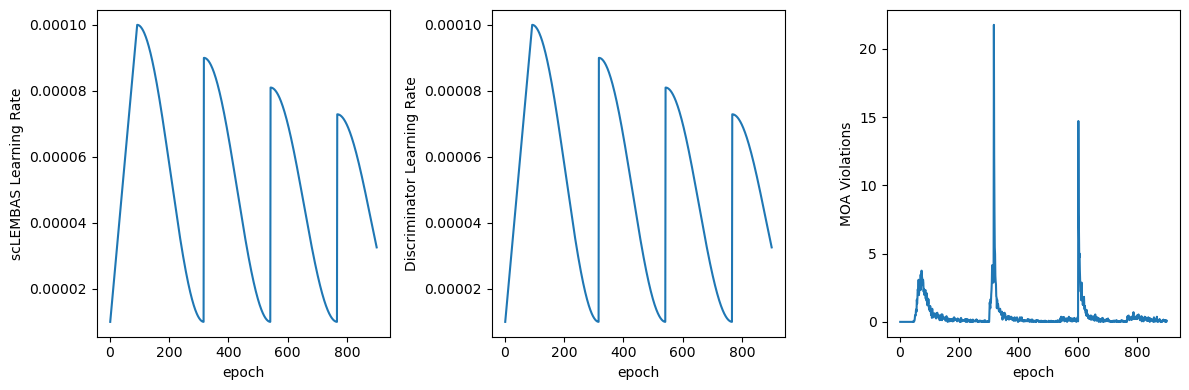

In [16]:
fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
ax[0].set_ylabel('scLEMBAS Learning Rate')

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'discriminator_learning_rate', ax = ax[1])
ax[1].set_ylabel('Discriminator Learning Rate')

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'n_moa_violations', ax = ax[2])
ax[2].set_ylabel('MOA Violations')

fig.tight_layout()

Let's also see what the loss looks like across epochs:

/tmp/ipykernel_3970011/2002301814.py:32: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)


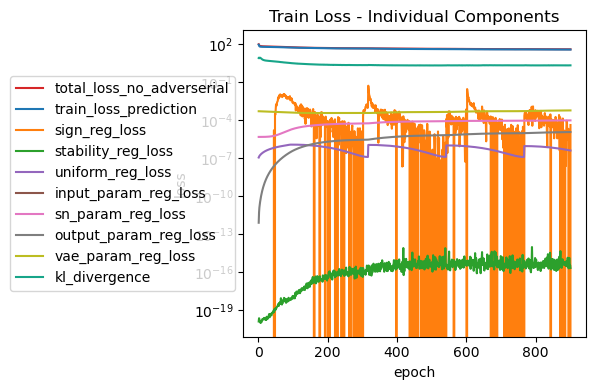

In [50]:
fig, ax = plt.subplots(ncols = 1, figsize = (8, 4))

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# # plot 1: no adverserial
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']


viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial'] + loss_cols_main)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)
# ax.set_yscale('log')
ax.legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax.set_title('Train Loss - Individual Components')
ax.set_yscale('log')

fig.tight_layout()